In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('motordata.csv')
df.head()

,time_ms,ax,ay,az,sound
0,125599,1855,1759,1703,746
1,125609,1823,1885,1461,1409
2,125619,1834,1911,1405,1254
3,125629,1805,1694,1737,83
4,125639,1782,1776,1598,898


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   time_ms  3550 non-null   int64
 1   ax       3550 non-null   int64
 2   ay       3550 non-null   int64
 3   az       3550 non-null   int64
 4   sound    3550 non-null   int64
dtypes: int64(5)
memory usage: 138.8 KB


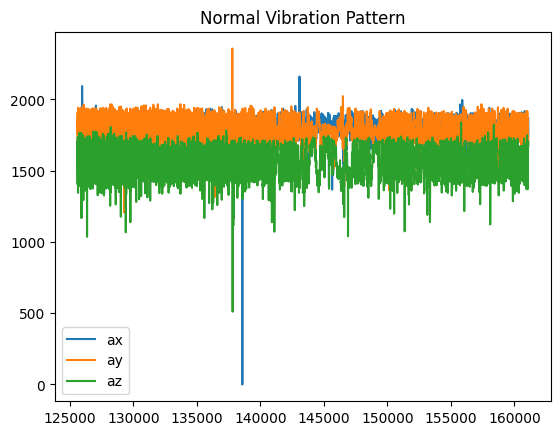

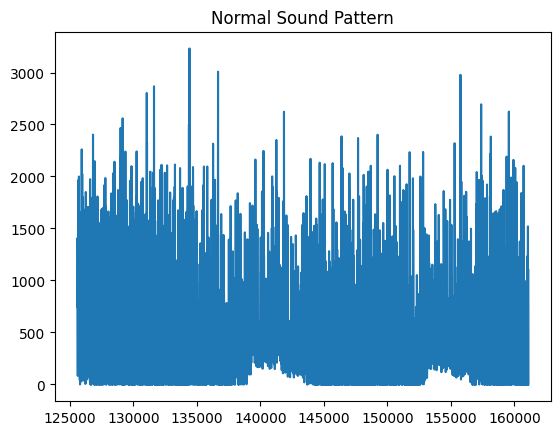

In [6]:
# Plot vibration
plt.figure()
plt.plot(df['time_ms'], df['ax'], label='ax')
plt.plot(df['time_ms'], df['ay'], label='ay')
plt.plot(df['time_ms'], df['az'], label='az')
plt.legend()
plt.title("Normal Vibration Pattern")
plt.show()

# Plot sound
plt.figure()
plt.plot(df['time_ms'], df['sound'])
plt.title("Normal Sound Pattern")
plt.show()

In [8]:
features= df[['ax','ay','az','sound']]

In [10]:
from sklearn.ensemble import IsolationForest
model= IsolationForest(n_estimators=200,contamination=0.03,random_state=42)
model.fit(features)

IsolationForest(contamination=0.05, random_state=42)

In [13]:
new_sample=[[1807,1941,1414,1079]]

In [14]:
new_df=pd.DataFrame(new_sample,columns=['ax','ay','az','sound'])
prediction=model.predict(new_df)
if prediction[0]==-1:
    print("Anomaly Detected")
else:
    print("Normal")

Normal


In [15]:
#Containerize the model
import joblib
joblib.dump(model,'isolation_forest_model.pkl')

['isolation_forest_model.pkl']